# Notebook 06 — Risk Evaluation

### This notebook answers the question:
- How useful is the champion model when an investigation team can only review a limited number of transactions?
We'll evaluate the model in terms of:
1. Risk-score distribution
2. Fraud concentration across risk bands
3. Investigation capacity
4. Precision at different operating points
5. Cumulative fraud capture
6. Business-oriented recommendations
- We won't immediately create arbitrary Low/Medium/High bands. First we'll understand how the score behaves.

# Step 36 — Load Champion Risk Scores

# Risk Evaluation

The XGBoost model was selected as the champion model based on global
discrimination performance and operational ranking performance.

This notebook evaluates how the champion model behaves as a transaction-risk
scoring system.

The analysis focuses on fraud concentration, investigation capacity, operating
thresholds, and business trade-offs.

The validation period was previously used for model comparison and threshold
analysis, so these results should be interpreted as model-development
evaluation rather than an untouched final test estimate.

In [1]:
# ============================================================
# STEP 36 — LOAD CHAMPION RISK SCORES
# ============================================================

import pandas as pd
import numpy as np

risk_path = "../data/processed/champion_risk_scores.csv"

risk_df = pd.read_csv(risk_path)

print("=" * 90)
print("CHAMPION RISK SCORE DATASET")
print("=" * 90)

print("Shape:", risk_df.shape)

print("\nColumns:")
print(risk_df.columns.tolist())

print("\nFirst 5 rows:")
display(risk_df.head())

print("\nTarget distribution:")
print(risk_df["isFraud"].value_counts())

print("\nFraud rate:")
print(f"{risk_df['isFraud'].mean():.4%}")

print("\nRisk score summary:")
print(risk_df["XGBoost_Risk_Score"].describe())

print("\nMissing values:")
print(risk_df.isna().sum())

print("\nRISK DATASET LOADED")

CHAMPION RISK SCORE DATASET
Shape: (118108, 4)

Columns:
['TransactionID', 'TransactionDT', 'isFraud', 'XGBoost_Risk_Score']

First 5 rows:


,TransactionID,TransactionDT,isFraud,XGBoost_Risk_Score
0,3459432,12192900,1,0.307689
1,3459433,12192911,0,0.093651
2,3459434,12192913,0,0.866763
3,3459435,12193040,0,0.953126
4,3459436,12193199,0,0.104399



Target distribution:
isFraud
0    114044
1      4064
Name: count, dtype: int64

Fraud rate:
3.4409%

Risk score summary:
count    118108.000000
mean          0.232785
std           0.211445
min           0.001653
25%           0.084568
50%           0.159963
75%           0.300729
max           0.999451
Name: XGBoost_Risk_Score, dtype: float64

Missing values:
TransactionID         0
TransactionDT         0
isFraud               0
XGBoost_Risk_Score    0
dtype: int64

RISK DATASET LOADED


## Step 37 — Risk Score Distribution

The champion XGBoost model produces a continuous risk score for every
transaction.

This analysis compares the score distributions of legitimate and fraudulent
transactions.

The objective is to determine whether fraudulent transactions are concentrated
toward higher-risk scores and whether the model provides meaningful separation
between the two classes.

The risk score is treated as a ranking signal rather than a calibrated
probability because class weighting was used during model training.

RISK SCORE DISTRIBUTION
Legitimate transactions: 114044
Fraudulent transactions: 4064

Mean risk score:
Legitimate: 0.2162
Fraudulent: 0.6986

Median risk score:
Legitimate: 0.1548
Fraudulent: 0.7698

75th percentile:
Legitimate: 0.2812
Fraudulent: 0.9674

90th percentile:
Legitimate: 0.4932
Fraudulent: 0.9941

95th percentile:
Legitimate: 0.6419
Fraudulent: 0.9970


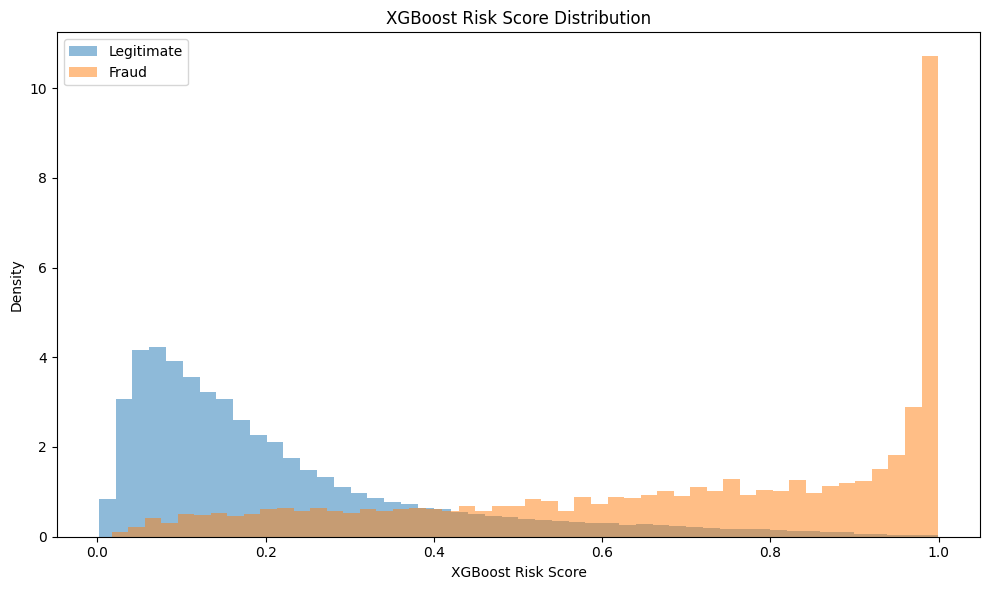


RISK SCORE DISTRIBUTION ANALYSIS COMPLETED


In [2]:
# ============================================================
# STEP 37 — RISK SCORE DISTRIBUTION
# ============================================================

import matplotlib.pyplot as plt

fraud_scores = risk_df.loc[
    risk_df["isFraud"] == 1,
    "XGBoost_Risk_Score"
]

legitimate_scores = risk_df.loc[
    risk_df["isFraud"] == 0,
    "XGBoost_Risk_Score"
]

print("=" * 90)
print("RISK SCORE DISTRIBUTION")
print("=" * 90)

print("Legitimate transactions:", len(legitimate_scores))
print("Fraudulent transactions:", len(fraud_scores))

print("\nMean risk score:")
print("Legitimate:", f"{legitimate_scores.mean():.4f}")
print("Fraudulent:", f"{fraud_scores.mean():.4f}")

print("\nMedian risk score:")
print("Legitimate:", f"{legitimate_scores.median():.4f}")
print("Fraudulent:", f"{fraud_scores.median():.4f}")

print("\n75th percentile:")
print("Legitimate:", f"{legitimate_scores.quantile(0.75):.4f}")
print("Fraudulent:", f"{fraud_scores.quantile(0.75):.4f}")

print("\n90th percentile:")
print("Legitimate:", f"{legitimate_scores.quantile(0.90):.4f}")
print("Fraudulent:", f"{fraud_scores.quantile(0.90):.4f}")

print("\n95th percentile:")
print("Legitimate:", f"{legitimate_scores.quantile(0.95):.4f}")
print("Fraudulent:", f"{fraud_scores.quantile(0.95):.4f}")

# ------------------------------------------------------------
# Plot score distributions
# ------------------------------------------------------------

plt.figure(figsize=(10, 6))

plt.hist(
    legitimate_scores,
    bins=50,
    density=True,
    alpha=0.5,
    label="Legitimate"
)

plt.hist(
    fraud_scores,
    bins=50,
    density=True,
    alpha=0.5,
    label="Fraud"
)

plt.xlabel("XGBoost Risk Score")
plt.ylabel("Density")
plt.title("XGBoost Risk Score Distribution")
plt.legend()
plt.tight_layout()
plt.show()

print("\nRISK SCORE DISTRIBUTION ANALYSIS COMPLETED")

### Analytical Observation

The XGBoost risk-score distribution shows strong separation between legitimate
and fraudulent transactions. Fraudulent transactions are heavily concentrated
toward higher risk scores, while legitimate transactions are more concentrated
toward lower scores.

The median risk score for fraudulent transactions (0.7698) is substantially
higher than that of legitimate transactions (0.1548), and the upper percentiles
of the fraud distribution are concentrated close to 1.0.

This indicates that the model is effective at ranking transactions according
to fraud risk. However, substantial overlap remains between the two classes,
so the risk score should be used as a prioritisation signal rather than a
perfect fraud/legitimate boundary.

The scores are treated as risk scores rather than calibrated fraud probabilities
because class weighting was used during model training.

## Step 38 — Fraud Concentration by Risk Band

To understand how the continuous XGBoost risk score translates into operational
risk levels, transactions are grouped into predefined risk-score bands.

For each band, we calculate transaction volume, fraudulent transactions,
fraud rate, and the proportion of all validation-set fraud captured.

Fraud rate measures the concentration of fraud within a band, while cumulative
fraud capture shows how much of the total observed fraud can be identified by
considering transactions up to a given risk threshold.

These results will be used to inform risk-band design and investigation
prioritisation rather than imposing an arbitrary threshold.

In [3]:
# ============================================================
# STEP 38 — FRAUD CONCENTRATION BY RISK BAND
# ============================================================

import pandas as pd
import numpy as np

# ------------------------------------------------------------
# 1. Define risk-score bands
# ------------------------------------------------------------

risk_bins = [
    0.0, 0.1, 0.2, 0.3, 0.4,
    0.5, 0.6, 0.7, 0.8, 0.9, 1.0
]

risk_labels = [
    "0.0–0.1",
    "0.1–0.2",
    "0.2–0.3",
    "0.3–0.4",
    "0.4–0.5",
    "0.5–0.6",
    "0.6–0.7",
    "0.7–0.8",
    "0.8–0.9",
    "0.9–1.0"
]

risk_df["Risk_Band"] = pd.cut(
    risk_df["XGBoost_Risk_Score"],
    bins=risk_bins,
    labels=risk_labels,
    include_lowest=True,
    right=True
)

# ------------------------------------------------------------
# 2. Calculate band-level metrics
# ------------------------------------------------------------

band_summary = (
    risk_df
    .groupby("Risk_Band", observed=False)
    .agg(
        Transactions=("isFraud", "size"),
        Fraudulent=("isFraud", "sum")
    )
    .reset_index()
)

# Fraud rate within each band
band_summary["Fraud_Rate"] = (
    band_summary["Fraudulent"]
    / band_summary["Transactions"]
)

# Percentage of all fraud represented by each band
total_fraud = risk_df["isFraud"].sum()

band_summary["Fraud_Capture"] = (
    band_summary["Fraudulent"]
    / total_fraud
)

# Cumulative fraud captured when moving from low to high risk
band_summary["Cumulative_Fraud_Capture"] = (
    band_summary["Fraudulent"]
    .cumsum()
    / total_fraud
)

# ------------------------------------------------------------
# 3. Display results
# ------------------------------------------------------------

print("=" * 100)
print("FRAUD CONCENTRATION BY RISK BAND")
print("=" * 100)

display(
    band_summary.style.format({
        "Fraud_Rate": "{:.2%}",
        "Fraud_Capture": "{:.2%}",
        "Cumulative_Fraud_Capture": "{:.2%}"
    })
)

print("\nTotal validation transactions:", len(risk_df))
print("Total validation fraud:", total_fraud)

print("\nRisk-band analysis completed.")

FRAUD CONCENTRATION BY RISK BAND


,Risk_Band,Transactions,Fraudulent,Fraud_Rate,Fraud_Capture,Cumulative_Fraud_Capture
0,0.0–0.1,36385,92,0.25%,2.26%,2.26%
1,0.1–0.2,33960,196,0.58%,4.82%,7.09%
2,0.2–0.3,18141,250,1.38%,6.15%,13.24%
3,0.3–0.4,9425,246,2.61%,6.05%,19.29%
4,0.4–0.5,6099,251,4.12%,6.18%,25.47%
5,0.5–0.6,4313,312,7.23%,7.68%,33.14%
6,0.6–0.7,3439,377,10.96%,9.28%,42.42%
7,0.7–0.8,2536,428,16.88%,10.53%,52.95%
8,0.8–0.9,1803,456,25.29%,11.22%,64.17%
9,0.9–1.0,2007,1456,72.55%,35.83%,100.00%



Total validation transactions: 118108
Total validation fraud: 4064

Risk-band analysis completed.


### Analytical Observation

Fraud concentration increases substantially as the XGBoost risk score increases.

Transactions with scores below 0.5 have relatively low fraud concentration,
while the fraud rate rises progressively across higher score bands. The
0.9–1.0 band contains only 1.70% of validation transactions but accounts for
35.83% of all observed fraud, with a within-band fraud rate of 72.55%.

This demonstrates that the model provides strong ranking capability and can
concentrate fraudulent transactions into a relatively small high-risk
population.

Based on the observed score distribution, an initial analytical segmentation
can be defined as Low Risk (<0.5), Medium Risk (0.5–0.9), and High Risk
(≥0.9). These bands are analytical operating segments rather than production
thresholds and would require validation on a future holdout before deployment.

# Step 39 — Operational Risk Bands


The continuous XGBoost risk score is converted into three analytical risk
segments to support operational interpretation:

- Low Risk: score < 0.5
- Medium Risk: score from 0.5 to <0.9
- High Risk: score ≥ 0.9

These bands are based on the fraud concentration observed in the validation
period. They are analytical segments rather than production thresholds.

For each segment, transaction volume, fraud count, fraud rate, and share of
total observed fraud are calculated.

The objective is to understand the trade-off between the size of the
population being monitored and the concentration of fraudulent transactions.

In [4]:
# ============================================================
# STEP 39 — OPERATIONAL RISK BANDS
# ============================================================

import pandas as pd
import numpy as np

# ------------------------------------------------------------
# 1. Assign analytical risk bands
# ------------------------------------------------------------

risk_df["Risk_Level"] = pd.cut(
    risk_df["XGBoost_Risk_Score"],
    bins=[-np.inf, 0.5, 0.9, np.inf],
    labels=["Low Risk", "Medium Risk", "High Risk"],
    right=False
)

# ------------------------------------------------------------
# 2. Calculate band-level metrics
# ------------------------------------------------------------

risk_band_summary = (
    risk_df
    .groupby("Risk_Level", observed=False)
    .agg(
        Transactions=("isFraud", "size"),
        Fraudulent=("isFraud", "sum")
    )
    .reset_index()
)

# Fraud rate within each risk band
risk_band_summary["Fraud_Rate"] = (
    risk_band_summary["Fraudulent"]
    / risk_band_summary["Transactions"]
)

# Percentage of all fraud contained in each band
total_fraud = risk_df["isFraud"].sum()

risk_band_summary["Fraud_Capture"] = (
    risk_band_summary["Fraudulent"]
    / total_fraud
)

# Percentage of all transactions in each band
total_transactions = len(risk_df)

risk_band_summary["Transaction_Share"] = (
    risk_band_summary["Transactions"]
    / total_transactions
)

# ------------------------------------------------------------
# 3. Display summary
# ------------------------------------------------------------

print("=" * 100)
print("OPERATIONAL RISK BAND ANALYSIS")
print("=" * 100)

display(
    risk_band_summary.style.format({
        "Fraud_Rate": "{:.2%}",
        "Fraud_Capture": "{:.2%}",
        "Transaction_Share": "{:.2%}"
    })
)

print("\nTotal validation transactions:", total_transactions)
print("Total validation fraud:", total_fraud)

print("\nRisk-band analysis completed.")

OPERATIONAL RISK BAND ANALYSIS


,Risk_Level,Transactions,Fraudulent,Fraud_Rate,Fraud_Capture,Transaction_Share
0,Low Risk,104010,1035,1.00%,25.47%,88.06%
1,Medium Risk,12091,1573,13.01%,38.71%,10.24%
2,High Risk,2007,1456,72.55%,35.83%,1.70%



Total validation transactions: 118108
Total validation fraud: 4064

Risk-band analysis completed.


### Analytical Observation

The proposed risk bands demonstrate strong operational separation.

The Low Risk segment contains 88.06% of validation transactions but has only
a 1.00% observed fraud rate. The Medium Risk segment represents 10.24% of
transactions and has a substantially higher fraud rate of 13.01%.

The High Risk segment is particularly concentrated: it represents only 1.70%
of validation transactions but contains 35.83% of all observed fraud, with an
observed within-band fraud rate of 72.55%.

This creates a practical risk hierarchy in which investigation resources can
be concentrated on a relatively small high-risk population while medium-risk
transactions can receive additional monitoring or selective review.

These risk bands are analytical operating segments derived from the validation
period and should be validated on a future holdout before production use.

## Step 40 — Investigation Capacity Analysis

A fraud detection system must operate under finite investigation capacity.
Therefore, model performance is evaluated by ranking transactions and
investigating only the highest-risk portion of the population.

Investigation capacity is expressed as the percentage of transactions that
can be reviewed.

For each capacity level, the analysis measures the number of transactions
reviewed, fraudulent transactions identified, precision among investigated
transactions, and the proportion of all observed fraud captured.

This provides an operational view of how the XGBoost risk ranking can support
prioritisation of manual investigations.

In [5]:
# ============================================================
# STEP 40 — INVESTIGATION CAPACITY ANALYSIS
# ============================================================

import pandas as pd
import numpy as np

# ------------------------------------------------------------
# 1. Define investigation capacities
# ------------------------------------------------------------

capacities = [0.01, 0.02, 0.05, 0.10, 0.20]

# Rank transactions from highest to lowest risk
ranked_risk_df = risk_df.sort_values(
    "XGBoost_Risk_Score",
    ascending=False
).reset_index(drop=True)

total_fraud = ranked_risk_df["isFraud"].sum()
total_transactions = len(ranked_risk_df)

capacity_results = []

# ------------------------------------------------------------
# 2. Evaluate each investigation capacity
# ------------------------------------------------------------

for capacity in capacities:

    k = int(np.ceil(total_transactions * capacity))

    top_k = ranked_risk_df.iloc[:k]

    transactions_investigated = len(top_k)
    fraud_found = top_k["isFraud"].sum()

    precision_at_k = (
        fraud_found / transactions_investigated
    )

    fraud_capture = (
        fraud_found / total_fraud
    )

    capacity_results.append({
        "Investigation_Capacity": capacity,
        "Transactions_Investigated": transactions_investigated,
        "Fraud_Found": fraud_found,
        "Precision_at_K": precision_at_k,
        "Fraud_Capture": fraud_capture
    })

capacity_summary = pd.DataFrame(capacity_results)

# ------------------------------------------------------------
# 3. Display results
# ------------------------------------------------------------

print("=" * 100)
print("INVESTIGATION CAPACITY ANALYSIS")
print("=" * 100)

display(
    capacity_summary.style.format({
        "Investigation_Capacity": "{:.0%}",
        "Precision_at_K": "{:.2%}",
        "Fraud_Capture": "{:.2%}"
    })
)

print("\nTotal validation transactions:", total_transactions)
print("Total validation fraud:", total_fraud)

print("\nINVESTIGATION CAPACITY ANALYSIS COMPLETED")

INVESTIGATION CAPACITY ANALYSIS


,Investigation_Capacity,Transactions_Investigated,Fraud_Found,Precision_at_K,Fraud_Capture
0,1%,1182,1031,87.23%,25.37%
1,2%,2363,1565,66.23%,38.51%
2,5%,5906,2274,38.50%,55.95%
3,10%,11811,2865,24.26%,70.50%
4,20%,23622,3385,14.33%,83.29%



Total validation transactions: 118108
Total validation fraud: 4064

INVESTIGATION CAPACITY ANALYSIS COMPLETED


### Analytical Observation

The XGBoost risk ranking demonstrates strong performance under constrained
investigation capacity.

At 1% investigation capacity, 87.23% of investigated transactions are
fraudulent and 25.37% of all observed fraud is captured. Increasing the
investigation capacity to 5% captures 55.95% of observed fraud, while a 10%
capacity captures 70.50%.

The results also demonstrate diminishing returns as investigation capacity
increases. Expanding investigation capacity from 10% to 20% doubles the number
of transactions reviewed but increases fraud capture by only 12.79 percentage
points.

This indicates that the risk score can be used to prioritise investigations
toward a relatively small high-risk population, with the appropriate operating
point determined by available investigation resources and the relative costs
of missed fraud and unnecessary review.

## Step 41 — Model Explainability: Global Feature Importance

The champion XGBoost model is examined to understand which transformed features
contribute most strongly to its predictions.

Global feature importance identifies features that the model relies on most
across the evaluated population.

This analysis is descriptive rather than causal. A highly important feature
indicates that the model uses the feature substantially when making predictions;
it does not establish that the feature causes fraud.

Because the IEEE-CIS dataset contains anonymized variables, the analysis will
retain the original feature names and will not assign unsupported business
interpretations to anonymized variables.

In [7]:
# ============================================================
# STEP 41B — LOAD CHAMPION MODEL ARTIFACTS
# ============================================================

import joblib
import os
import time

start_time = time.time()

artifact_dir = "../data/processed/model_artifacts"

preprocessor_path = (
    f"{artifact_dir}/xgboost_preprocessor.joblib"
)

model_path = (
    f"{artifact_dir}/xgboost_champion_model.joblib"
)

feature_names_path = (
    f"{artifact_dir}/xgboost_feature_names.joblib"
)

# ------------------------------------------------------------
# 1. Check artifact files
# ------------------------------------------------------------

required_files = [
    preprocessor_path,
    model_path,
    feature_names_path
]

for path in required_files:
    assert os.path.exists(path), (
        f"Missing artifact: {path}"
    )

# ------------------------------------------------------------
# 2. Load artifacts
# ------------------------------------------------------------

final_preprocessor = joblib.load(
    preprocessor_path
)

champion_model = joblib.load(
    model_path
)

feature_names = joblib.load(
    feature_names_path
)

elapsed_time = time.time() - start_time

# ------------------------------------------------------------
# 3. Validate loaded objects
# ------------------------------------------------------------

print("=" * 100)
print("CHAMPION MODEL ARTIFACTS LOADED")
print("=" * 100)

print("Preprocessor type:", type(final_preprocessor).__name__)
print("Model type:", type(champion_model).__name__)

print("Transformed feature names:", len(feature_names))
print(
    "Model feature importance values:",
    len(champion_model.feature_importances_)
)

assert len(feature_names) == len(
    champion_model.feature_importances_
), "Feature-name alignment failed."

print("\nTime taken:", f"{elapsed_time:.2f} seconds")

print("\nMODEL ARTIFACT VALIDATION PASSED")

CHAMPION MODEL ARTIFACTS LOADED
Preprocessor type: ColumnTransformer
Model type: XGBClassifier
Transformed feature names: 768
Model feature importance values: 768

Time taken: 1.29 seconds

MODEL ARTIFACT VALIDATION PASSED


MODEL EXPLAINABILITY — GLOBAL FEATURE IMPORTANCE
Number of transformed features: 768
Number of model importance values: 768

Top 20 transformed features:


,Feature,Importance
0,numerical__V264,0.095693
1,numerical__V258,0.067116
2,numerical__V218,0.047512
3,numerical__V91,0.036086
4,numerical__V70,0.035579
5,numerical__V295,0.029348
6,numerical__V294,0.028265
7,numerical__C4,0.021345
8,numerical__C8,0.018207
9,numerical__V201,0.012788


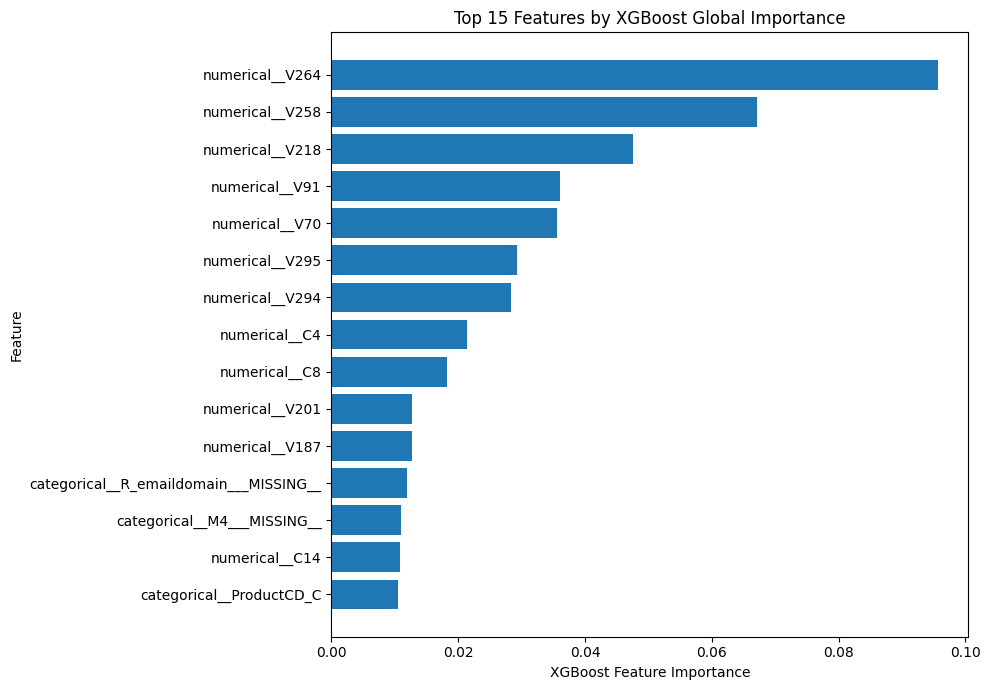


MODEL EXPLAINABILITY ANALYSIS COMPLETED


In [8]:
# ============================================================
# STEP 41 — GLOBAL FEATURE IMPORTANCE
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1. Get transformed feature names
# ------------------------------------------------------------

feature_names = final_preprocessor.get_feature_names_out()

# Confirm alignment with the XGBoost model
importance_values = champion_model.feature_importances_

print("=" * 100)
print("MODEL EXPLAINABILITY — GLOBAL FEATURE IMPORTANCE")
print("=" * 100)

print("Number of transformed features:", len(feature_names))
print("Number of model importance values:", len(importance_values))

assert len(feature_names) == len(importance_values), (
    "Feature-name and importance lengths do not match."
)

# ------------------------------------------------------------
# 2. Build feature importance table
# ------------------------------------------------------------

feature_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance_values
})

feature_importance_df = (
    feature_importance_df
    .sort_values("Importance", ascending=False)
    .reset_index(drop=True)
)

# ------------------------------------------------------------
# 3. Display top 20 features
# ------------------------------------------------------------

print("\nTop 20 transformed features:")

display(
    feature_importance_df.head(20)
)

# ------------------------------------------------------------
# 4. Plot top 15 features
# ------------------------------------------------------------

top_features = (
    feature_importance_df
    .head(15)
    .sort_values("Importance", ascending=True)
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.xlabel("XGBoost Feature Importance")
plt.ylabel("Feature")
plt.title("Top 15 Features by XGBoost Global Importance")
plt.tight_layout()
plt.show()

print("\nMODEL EXPLAINABILITY ANALYSIS COMPLETED")

## Step 41A — Save Global Feature Importance

The global feature-importance results from the champion XGBoost model are
saved as a reusable analysis artifact.

This provides a record of the features most heavily used by the model and
allows the explainability analysis to be reproduced without retraining the
model.

In [9]:
# ============================================================
# STEP 41A — SAVE GLOBAL FEATURE IMPORTANCE
# ============================================================

output_path = "../data/processed/xgboost_feature_importance.csv"

feature_importance_df.to_csv(
    output_path,
    index=False
)

print("=" * 100)
print("GLOBAL FEATURE IMPORTANCE SAVED")
print("=" * 100)

print("Total transformed features:", len(feature_importance_df))
print("Top feature:", feature_importance_df.iloc[0]["Feature"])
print(
    "Top feature importance:",
    feature_importance_df.iloc[0]["Importance"]
)

print("\nSaved to:")
print(output_path)

print("\nGLOBAL FEATURE IMPORTANCE ARTIFACT SAVED")

GLOBAL FEATURE IMPORTANCE SAVED
Total transformed features: 768
Top feature: numerical__V264
Top feature importance: 0.095693275

Saved to:
../data/processed/xgboost_feature_importance.csv

GLOBAL FEATURE IMPORTANCE ARTIFACT SAVED


## Step 42 — Permutation Importance

Permutation importance is used to estimate the predictive contribution of the
most important transformed features identified by the XGBoost model.

For each selected feature, its values are randomly permuted while all other
features remain unchanged. The resulting change in PR-AUC measures how much
the model's predictive performance depends on that feature.

PR-AUC is used because the fraud class is highly imbalanced.

The analysis is performed on a 10,000-row sample of the validation period and
is limited to the top 20 globally important transformed features to control
computational cost.

Only the sampled validation rows are transformed. The full validation
transformed matrix is not materialized, reducing memory usage.

Permutation importance measures predictive contribution and should not be
interpreted as evidence of causality.

In [11]:
# ============================================================
# STEP 42 — PERMUTATION IMPORTANCE
# ============================================================

import numpy as np
import pandas as pd
import time

from sklearn.metrics import average_precision_score
from tqdm.auto import tqdm

# ------------------------------------------------------------
# 1. Load validation features
# ------------------------------------------------------------

validation_path = "../data/processed/validation_features.csv"

validation_df = pd.read_csv(
    validation_path
)

target = "isFraud"

X_validation = validation_df.drop(
    columns=[target]
)

y_validation = validation_df[target]

print("=" * 100)
print("PERMUTATION IMPORTANCE")
print("=" * 100)

print("Validation dataset shape:", validation_df.shape)

# ------------------------------------------------------------
# 2. Select a manageable validation sample
# ------------------------------------------------------------

sample_size = min(
    10_000,
    len(X_validation)
)

rng = np.random.default_rng(42)

sample_indices = rng.choice(
    len(X_validation),
    size=sample_size,
    replace=False
)

X_sample = X_validation.iloc[
    sample_indices
].copy()

y_sample = y_validation.iloc[
    sample_indices
].to_numpy()

print("Validation sample size:", sample_size)
print(
    "Fraud rate in sample:",
    f"{y_sample.mean():.4%}"
)

# ------------------------------------------------------------
# 3. Transform ONLY the sampled validation rows
# ------------------------------------------------------------

start_time = time.time()

X_sample_transformed = final_preprocessor.transform(
    X_sample
)

transform_time = time.time() - start_time

print(
    "Sample transformed shape:",
    X_sample_transformed.shape
)

print(
    "Sample transformation time:",
    f"{transform_time:.2f} seconds"
)

# ------------------------------------------------------------
# 4. Convert only the small sample to float32 dense
# ------------------------------------------------------------

X_perm = X_sample_transformed.toarray().astype(
    np.float32
)

print(
    "Dense permutation matrix shape:",
    X_perm.shape
)

print(
    "Approximate dense matrix memory:",
    f"{X_perm.nbytes / (1024 ** 2):.2f} MB"
)

# ------------------------------------------------------------
# 5. Select top 20 globally important features
# ------------------------------------------------------------

top_n = 20

top_features = (
    feature_importance_df
    .head(top_n)["Feature"]
    .tolist()
)

feature_name_to_index = {
    feature: index
    for index, feature in enumerate(feature_names)
}

top_feature_indices = [
    feature_name_to_index[feature]
    for feature in top_features
]

print("\nFeatures selected:", len(top_features))
print("Permutations per feature:", 3)
print("Evaluation metric: PR-AUC")

# ------------------------------------------------------------
# 6. Calculate baseline PR-AUC
# ------------------------------------------------------------

start_time = time.time()

baseline_scores = champion_model.predict_proba(
    X_perm
)[:, 1]

baseline_pr_auc = average_precision_score(
    y_sample,
    baseline_scores
)

baseline_time = time.time() - start_time

print(
    "\nBaseline PR-AUC:",
    f"{baseline_pr_auc:.4f}"
)

print(
    "Baseline prediction time:",
    f"{baseline_time:.2f} seconds"
)

# ------------------------------------------------------------
# 7. Permute each selected feature
# ------------------------------------------------------------

n_repeats = 3

permutation_results = []

start_time = time.time()

for feature, feature_index in tqdm(
    zip(top_features, top_feature_indices),
    total=len(top_features),
    desc="Permuting top features"
):

    original_column = X_perm[
        :, feature_index
    ].copy()

    repeat_drops = []

    for repeat in range(n_repeats):

        # Create a copy for this permutation
        X_shuffled = X_perm.copy()

        shuffled_column = original_column.copy()

        rng.shuffle(
            shuffled_column
        )

        X_shuffled[
            :, feature_index
        ] = shuffled_column

        # Predict after permutation
        shuffled_scores = champion_model.predict_proba(
            X_shuffled
        )[:, 1]

        shuffled_pr_auc = average_precision_score(
            y_sample,
            shuffled_scores
        )

        pr_auc_drop = (
            baseline_pr_auc
            - shuffled_pr_auc
        )

        repeat_drops.append(
            pr_auc_drop
        )

    permutation_results.append({
        "Feature": feature,
        "Baseline_PR_AUC": baseline_pr_auc,
        "Mean_PR_AUC_Drop": np.mean(repeat_drops),
        "Std_PR_AUC_Drop": np.std(repeat_drops)
    })

elapsed_time = time.time() - start_time

# ------------------------------------------------------------
# 8. Rank features by permutation importance
# ------------------------------------------------------------

permutation_importance_df = (
    pd.DataFrame(permutation_results)
    .sort_values(
        "Mean_PR_AUC_Drop",
        ascending=False
    )
    .reset_index(drop=True)
)

# ------------------------------------------------------------
# 9. Display results
# ------------------------------------------------------------

print("\n" + "=" * 100)
print("PERMUTATION IMPORTANCE RESULTS")
print("=" * 100)

display(
    permutation_importance_df.style.format({
        "Baseline_PR_AUC": "{:.4f}",
        "Mean_PR_AUC_Drop": "{:.6f}",
        "Std_PR_AUC_Drop": "{:.6f}"
    })
)

print(
    "\nPermutation analysis time:",
    f"{elapsed_time:.2f} seconds"
)

print("\nPERMUTATION IMPORTANCE ANALYSIS COMPLETED")

PERMUTATION IMPORTANCE
Validation dataset shape: (118108, 434)
Validation sample size: 10000
Fraud rate in sample: 3.2900%
Sample transformed shape: (10000, 768)
Sample transformation time: 0.27 seconds
Dense permutation matrix shape: (10000, 768)
Approximate dense matrix memory: 29.30 MB

Features selected: 20
Permutations per feature: 3
Evaluation metric: PR-AUC

Baseline PR-AUC: 0.1750
Baseline prediction time: 0.04 seconds


Permuting top features:   0%|          | 0/20 [00:00<?, ?it/s]


PERMUTATION IMPORTANCE RESULTS


,Feature,Baseline_PR_AUC,Mean_PR_AUC_Drop,Std_PR_AUC_Drop
0,numerical__V258,0.1750,0.031544,0.001859
1,numerical__C4,0.1750,0.012022,0.000182
2,numerical__C8,0.1750,0.009698,0.000962
3,numerical__V201,0.1750,0.007939,0.000163
4,numerical__V257,0.1750,0.007629,0.000214
5,numerical__V294,0.1750,0.005251,0.000972
6,numerical__V264,0.1750,0.002723,0.000439
7,numerical__V312,0.1750,0.000878,0.000159
8,numerical__V218,0.1750,0.000868,0.000245
9,numerical__V308,0.1750,0.000421,0.000390



Permutation analysis time: 1.11 seconds

PERMUTATION IMPORTANCE ANALYSIS COMPLETED


## Step 42A — Save Permutation Importance

The permutation-importance results are saved as a reproducible explainability
artifact.

The results provide a complementary view of feature contribution relative to
the model's built-in global feature importance.

Small negative permutation scores are treated as sampling or permutation
variability rather than evidence that a feature should be removed.

In [12]:
# ============================================================
# STEP 42A — SAVE PERMUTATION IMPORTANCE
# ============================================================

output_path = (
    "../data/processed/xgboost_permutation_importance.csv"
)

permutation_importance_df.to_csv(
    output_path,
    index=False
)

print("=" * 100)
print("PERMUTATION IMPORTANCE SAVED")
print("=" * 100)

print(
    "Features evaluated:",
    len(permutation_importance_df)
)

print(
    "Most important feature:",
    permutation_importance_df.iloc[0]["Feature"]
)

print(
    "Largest mean PR-AUC drop:",
    f"{permutation_importance_df.iloc[0]['Mean_PR_AUC_Drop']:.6f}"
)

print("\nSaved to:")
print(output_path)

print("\nPERMUTATION IMPORTANCE ARTIFACT SAVED")

PERMUTATION IMPORTANCE SAVED
Features evaluated: 20
Most important feature: numerical__V258
Largest mean PR-AUC drop: 0.031544

Saved to:
../data/processed/xgboost_permutation_importance.csv

PERMUTATION IMPORTANCE ARTIFACT SAVED


## Step 43 — SHAP-Based Model Explainability

SHAP contribution values are used to examine how individual transformed
features influence XGBoost predictions.

The analysis estimates the contribution of each feature to the model output
for a sample of validation transactions.

Positive contributions push a transaction toward a higher fraud-risk
prediction, while negative contributions push the prediction toward a lower
fraud-risk prediction.

The analysis is descriptive rather than causal. An individual feature's
contribution does not imply that the feature causes fraud.

Only a 1,000-row validation sample is analyzed to maintain computational and
memory efficiency.

In [13]:
# ============================================================
# STEP 43 — SHAP-STYLE FEATURE CONTRIBUTIONS FROM XGBOOST
# ============================================================

import numpy as np
import pandas as pd
import time

from xgboost import DMatrix

# ------------------------------------------------------------
# 1. Load validation data
# ------------------------------------------------------------

validation_path = (
    "../data/processed/validation_features.csv"
)

validation_df = pd.read_csv(
    validation_path
)

target = "isFraud"

X_validation = validation_df.drop(
    columns=[target]
)

y_validation = validation_df[target]

# ------------------------------------------------------------
# 2. Sample 1,000 validation transactions
# ------------------------------------------------------------

sample_size = min(
    1_000,
    len(X_validation)
)

rng = np.random.default_rng(42)

sample_indices = rng.choice(
    len(X_validation),
    size=sample_size,
    replace=False
)

X_sample = X_validation.iloc[
    sample_indices
].copy()

y_sample = y_validation.iloc[
    sample_indices
].to_numpy()

print("=" * 100)
print("SHAP-STYLE MODEL EXPLAINABILITY")
print("=" * 100)

print("Validation sample size:", sample_size)
print(
    "Fraud rate in sample:",
    f"{y_sample.mean():.4%}"
)

# ------------------------------------------------------------
# 3. Transform sampled validation data
# ------------------------------------------------------------

start_time = time.time()

X_sample_transformed = final_preprocessor.transform(
    X_sample
)

print(
    "Transformed shape:",
    X_sample_transformed.shape
)

print(
    "Transformation time:",
    f"{time.time() - start_time:.2f} seconds"
)

# ------------------------------------------------------------
# 4. Generate XGBoost contribution values
# ------------------------------------------------------------

start_time = time.time()

booster = champion_model.get_booster()

dmatrix = DMatrix(
    X_sample_transformed
)

contributions = booster.predict(
    dmatrix,
    pred_contribs=True
)

elapsed_time = time.time() - start_time

print(
    "Contribution matrix shape:",
    contributions.shape
)

print(
    "Contribution calculation time:",
    f"{elapsed_time:.2f} seconds"
)

# ------------------------------------------------------------
# 5. Validate dimensions
# ------------------------------------------------------------

expected_columns = len(feature_names) + 1

print(
    "Expected contribution columns:",
    expected_columns
)

assert contributions.shape == (
    sample_size,
    expected_columns
), "Contribution matrix shape mismatch."

# Last column is the model bias/base value
feature_contributions = contributions[:, :-1]

# ------------------------------------------------------------
# 6. Calculate mean absolute contribution
# ------------------------------------------------------------

mean_abs_contribution = np.mean(
    np.abs(feature_contributions),
    axis=0
)

mean_signed_contribution = np.mean(
    feature_contributions,
    axis=0
)

shap_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Mean_Abs_Contribution": mean_abs_contribution,
    "Mean_Signed_Contribution": mean_signed_contribution
})

shap_importance_df = (
    shap_importance_df
    .sort_values(
        "Mean_Abs_Contribution",
        ascending=False
    )
    .reset_index(drop=True)
)

# ------------------------------------------------------------
# 7. Display top 20 features
# ------------------------------------------------------------

print("\n" + "=" * 100)
print("TOP FEATURES BY MEAN ABSOLUTE CONTRIBUTION")
print("=" * 100)

display(
    shap_importance_df.head(20).style.format({
        "Mean_Abs_Contribution": "{:.6f}",
        "Mean_Signed_Contribution": "{:.6f}"
    })
)

print("\nSHAP-STYLE EXPLAINABILITY ANALYSIS COMPLETED")

SHAP-STYLE MODEL EXPLAINABILITY
Validation sample size: 1000
Fraud rate in sample: 2.7000%
Transformed shape: (1000, 768)
Transformation time: 0.03 seconds
Contribution matrix shape: (1000, 769)
Contribution calculation time: 0.31 seconds
Expected contribution columns: 769

TOP FEATURES BY MEAN ABSOLUTE CONTRIBUTION


,Feature,Mean_Abs_Contribution,Mean_Signed_Contribution
0,numerical__C14,0.203904,-0.111137
1,numerical__V258,0.195252,-0.134773
2,numerical__TransactionAmt,0.160788,-0.038571
3,numerical__C13,0.153815,-0.054478
4,categorical__card6_debit,0.133477,-0.029996
5,numerical__C1,0.131180,-0.039623
6,numerical__C11,0.130690,-0.023588
7,numerical__V70,0.119626,-0.041578
8,numerical__V294,0.113493,-0.040553
9,numerical__card1,0.101604,-0.046473



SHAP-STYLE EXPLAINABILITY ANALYSIS COMPLETED


## Step 43A — Save SHAP-Based Feature Contributions

The SHAP-style feature contribution results are saved as a model
explainability artifact.

Mean absolute contribution is used to rank features by the magnitude of their
influence on model predictions, while mean signed contribution describes the
average direction of contribution within the analyzed validation sample.

These results describe predictive behavior and do not establish causal
relationships between features and fraud.

In [14]:
# ============================================================
# STEP 43A — SAVE SHAP-STYLE FEATURE CONTRIBUTIONS
# ============================================================

output_path = (
    "../data/processed/xgboost_shap_importance.csv"
)

shap_importance_df.to_csv(
    output_path,
    index=False
)

print("=" * 100)
print("SHAP-STYLE FEATURE CONTRIBUTIONS SAVED")
print("=" * 100)

print(
    "Features evaluated:",
    len(shap_importance_df)
)

print(
    "Top feature:",
    shap_importance_df.iloc[0]["Feature"]
)

print(
    "Top mean absolute contribution:",
    f"{shap_importance_df.iloc[0]['Mean_Abs_Contribution']:.6f}"
)

print("\nSaved to:")
print(output_path)

print("\nSHAP-STYLE EXPLAINABILITY ARTIFACT SAVED")

SHAP-STYLE FEATURE CONTRIBUTIONS SAVED
Features evaluated: 768
Top feature: numerical__C14
Top mean absolute contribution: 0.203904

Saved to:
../data/processed/xgboost_shap_importance.csv

SHAP-STYLE EXPLAINABILITY ARTIFACT SAVED


## Step 44 — Business Impact & Investigation Strategy

The fraud-risk model is evaluated from an operational perspective by
considering different investigation-capacity levels.

Transactions are ranked by XGBoost risk score, and only the highest-risk
transactions within each capacity level are investigated.

The analysis considers investigation workload, fraud concentration, fraud
capture, and false-positive workload.

These results describe potential operating scenarios rather than production
policies. The final operating point would depend on investigation capacity,
fraud-loss severity, customer-friction costs, operational constraints, and
business requirements.

In [15]:
# ============================================================
# STEP 44 — BUSINESS IMPACT & INVESTIGATION STRATEGY
# ============================================================

import pandas as pd
import numpy as np

# ------------------------------------------------------------
# 1. Define investigation-capacity scenarios
# ------------------------------------------------------------

capacity_levels = [0.01, 0.02, 0.05, 0.10, 0.20]

business_results = []

total_transactions = len(risk_df)
total_fraud = risk_df["isFraud"].sum()
baseline_fraud_rate = risk_df["isFraud"].mean()

# Rank transactions from highest to lowest XGBoost risk score
ranked_risk_df = risk_df.sort_values(
    "XGBoost_Risk_Score",
    ascending=False
).reset_index(drop=True)

# ------------------------------------------------------------
# 2. Evaluate each investigation capacity
# ------------------------------------------------------------

for capacity in capacity_levels:

    investigation_count = int(
        np.ceil(total_transactions * capacity)
    )

    investigated = ranked_risk_df.iloc[
        :investigation_count
    ]

    fraud_found = investigated["isFraud"].sum()

    false_positives = (
        investigation_count - fraud_found
    )

    precision = (
        fraud_found / investigation_count
    )

    fraud_capture = (
        fraud_found / total_fraud
    )

    lift = (
        precision / baseline_fraud_rate
    )

    business_results.append({
        "Investigation_Capacity": f"{capacity:.0%}",
        "Transactions_Investigated": investigation_count,
        "Fraud_Found": int(fraud_found),
        "False_Positives": int(false_positives),
        "Precision_at_K": precision,
        "Fraud_Capture": fraud_capture,
        "Lift_vs_Baseline": lift
    })

business_impact_df = pd.DataFrame(
    business_results
)

# ------------------------------------------------------------
# 3. Display business impact
# ------------------------------------------------------------

print("=" * 110)
print("BUSINESS IMPACT & INVESTIGATION STRATEGY")
print("=" * 110)

print(
    "Total validation transactions:",
    total_transactions
)

print(
    "Total validation fraud:",
    total_fraud
)

print(
    "Baseline fraud rate:",
    f"{baseline_fraud_rate:.4%}"
)

print()

display(
    business_impact_df.style.format({
        "Precision_at_K": "{:.2%}",
        "Fraud_Capture": "{:.2%}",
        "Lift_vs_Baseline": "{:.2f}x"
    })
)

print("\nBUSINESS IMPACT ANALYSIS COMPLETED")

BUSINESS IMPACT & INVESTIGATION STRATEGY
Total validation transactions: 118108
Total validation fraud: 4064
Baseline fraud rate: 3.4409%



,Investigation_Capacity,Transactions_Investigated,Fraud_Found,False_Positives,Precision_at_K,Fraud_Capture,Lift_vs_Baseline
0,1%,1182,1031,151,87.23%,25.37%,25.35x
1,2%,2363,1565,798,66.23%,38.51%,19.25x
2,5%,5906,2274,3632,38.50%,55.95%,11.19x
3,10%,11811,2865,8946,24.26%,70.50%,7.05x
4,20%,23622,3385,20237,14.33%,83.29%,4.16x



BUSINESS IMPACT ANALYSIS COMPLETED


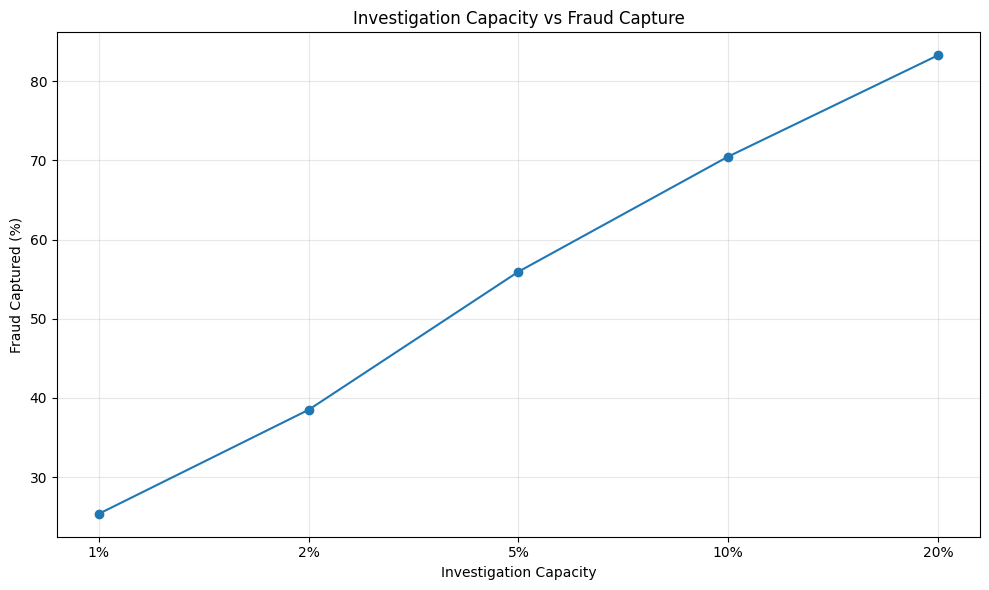

In [16]:
# ============================================================
# STEP 44B — INVESTIGATION CAPACITY VS FRAUD CAPTURE
# ============================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.plot(
    business_impact_df["Investigation_Capacity"],
    business_impact_df["Fraud_Capture"] * 100,
    marker="o"
)

plt.xlabel("Investigation Capacity")
plt.ylabel("Fraud Captured (%)")
plt.title(
    "Investigation Capacity vs Fraud Capture"
)

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [17]:
# ============================================================
# STEP 44C — FRAUD CONCENTRATION / LIFT
# ============================================================

lift_summary = business_impact_df[
    [
        "Investigation_Capacity",
        "Transactions_Investigated",
        "Fraud_Found",
        "Precision_at_K",
        "Fraud_Capture",
        "Lift_vs_Baseline"
    ]
].copy()

print("=" * 100)
print("FRAUD CONCENTRATION AND LIFT")
print("=" * 100)

display(
    lift_summary.style.format({
        "Precision_at_K": "{:.2%}",
        "Fraud_Capture": "{:.2%}",
        "Lift_vs_Baseline": "{:.2f}x"
    })
)

print("\nFRAUD CONCENTRATION ANALYSIS COMPLETED")

FRAUD CONCENTRATION AND LIFT


,Investigation_Capacity,Transactions_Investigated,Fraud_Found,Precision_at_K,Fraud_Capture,Lift_vs_Baseline
0,1%,1182,1031,87.23%,25.37%,25.35x
1,2%,2363,1565,66.23%,38.51%,19.25x
2,5%,5906,2274,38.50%,55.95%,11.19x
3,10%,11811,2865,24.26%,70.50%,7.05x
4,20%,23622,3385,14.33%,83.29%,4.16x



FRAUD CONCENTRATION ANALYSIS COMPLETED


## Step 45 — Final Business Recommendation

The XGBoost model demonstrates that transaction-level fraud risk can be
effectively ranked to concentrate fraudulent transactions near the top of the
investigation queue.

The model achieved strong discrimination on the temporally separated
validation period, with PR-AUC of approximately 0.51 and ROC-AUC of
approximately 0.90.

Operational analysis showed substantial fraud concentration:

- Investigating the top 1% of transactions achieved approximately 87%
  precision and captured approximately 25% of observed fraud.
- Investigating the top 5% achieved approximately 39% precision and captured
  approximately 56% of observed fraud.
- Investigating the top 10% achieved approximately 24% precision and captured
  approximately 71% of observed fraud.

Therefore, the model should be used primarily as a risk-ranking system rather
than as a fixed binary classifier.

A practical implementation would assign investigation priority according to
risk score and available investigation capacity. The highest-risk
transactions can receive immediate review, while progressively lower-risk
transactions can be reviewed when additional operational capacity is
available.

The final operating point should be determined using actual investigation
capacity, fraud-loss severity, customer-friction costs, and business
requirements. The illustrative cost-sensitive analysis demonstrates how the
operating threshold can change as the relative cost of missed fraud changes.

The model's feature importance and contribution analyses provide
interpretability into predictive behavior, but the anonymized dataset prevents
business interpretation of individual V- and C-family variables.

The validation period has already been used for model comparison and operating
point analysis. Consequently, these results should not be presented as an
untouched final production estimate. A separate future holdout would be
required for unbiased final evaluation before deployment.

In [18]:
# ============================================================
# STEP 45 — FINAL BUSINESS RECOMMENDATION SUMMARY
# ============================================================

final_recommendation = {
    "Champion_Model": "XGBoost",
    "Validation_PR_AUC": 0.5099,
    "Validation_ROC_AUC": 0.9041,
    "Baseline_Fraud_Rate": baseline_fraud_rate,
    "Top_1_Percent_Precision": 0.8723,
    "Top_1_Percent_Fraud_Capture": 0.2537,
    "Top_5_Percent_Precision": 0.3850,
    "Top_5_Percent_Fraud_Capture": 0.5595,
    "Top_10_Percent_Precision": 0.2426,
    "Top_10_Percent_Fraud_Capture": 0.7050
}

final_recommendation_df = pd.DataFrame(
    [final_recommendation]
)

print("=" * 100)
print("FINAL BUSINESS RECOMMENDATION")
print("=" * 100)

display(
    final_recommendation_df.style.format({
        "Validation_PR_AUC": "{:.4f}",
        "Validation_ROC_AUC": "{:.4f}",
        "Baseline_Fraud_Rate": "{:.2%}",
        "Top_1_Percent_Precision": "{:.2%}",
        "Top_1_Percent_Fraud_Capture": "{:.2%}",
        "Top_5_Percent_Precision": "{:.2%}",
        "Top_5_Percent_Fraud_Capture": "{:.2%}",
        "Top_10_Percent_Precision": "{:.2%}",
        "Top_10_Percent_Fraud_Capture": "{:.2%}"
    })
)

print("\nFINAL BUSINESS RECOMMENDATION GENERATED")

FINAL BUSINESS RECOMMENDATION


,Champion_Model,Validation_PR_AUC,Validation_ROC_AUC,Baseline_Fraud_Rate,Top_1_Percent_Precision,Top_1_Percent_Fraud_Capture,Top_5_Percent_Precision,Top_5_Percent_Fraud_Capture,Top_10_Percent_Precision,Top_10_Percent_Fraud_Capture
0,XGBoost,0.5099,0.9041,3.44%,87.23%,25.37%,38.50%,55.95%,24.26%,70.50%



FINAL BUSINESS RECOMMENDATION GENERATED


# Final Conclusion

The fraud detection pipeline converts transaction-level data into a ranked
fraud-risk system designed for limited investigation capacity.

The XGBoost model was selected as the champion because it provided strong
discrimination while performing slightly better than the other models at
practical investigation capacities.

On the validation period, the model achieved a PR-AUC of 0.5099 and ROC-AUC
of 0.9041.

The strongest operational result occurred in the highest-risk portion of the
ranking: investigating approximately the top 1% of transactions produced an
observed fraud precision of approximately 87%, while capturing approximately
25% of all fraud in the validation period.

Increasing investigation capacity to approximately 5% captured approximately
56% of fraud at approximately 39% precision, while 10% capacity captured
approximately 71% of fraud at approximately 24% precision.

These results demonstrate the value of risk ranking under constrained
investigation capacity.

The selected operating point should ultimately depend on actual fraud losses,
investigation costs, customer friction, operational capacity, and business
requirements. The cost scenarios evaluated in this project are illustrative
rather than production estimates.

Because the validation period was used during model comparison and operating
point analysis, it should not be interpreted as an untouched final test set.
A separate future holdout would be required before production deployment.